# Phishing URL Detection — Exploratory Data Analysis

Exploratory analysis of the **raw dataset**: URL strings and their binary labels (phishing / legitimate).

> **Dataset shape:** ~5.18 M URLs · 2 columns (`url`, `label`)
> **Next step:** `02_feature_engineering.ipynb` — extract 25 structural features and validate them visually.

## Table of Contents
1. [Library Imports](#section-1)
2. [Load and Aggregate Dataset](#section-2)
3. [Raw Data Exploration](#section-3)
   - 3.1 Class distribution
   - 3.2 Random URL samples
   - 3.3 URL length distribution by class
   - 3.4 TLD frequency by class
4. [Key Takeaways](#section-4)

## SECTION 1 — Library Imports

All imports and project-wide constants defined here.

In [37]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import tldextract

pd.set_option('display.max_colwidth', 140)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (12, 5)})

# ── Project-wide constants ───────────────────────────────────────────────────
CLASS_LABELS = {0: 'Legitimate', 1: 'Phishing'}
CLASS_ORDER  = ['Legitimate', 'Phishing']
CLASS_COLORS = {'Legitimate': '#239DD9', 'Phishing': '#FF911E'}

print('Libraries imported successfully.')

Libraries imported successfully.


## SECTION 2 — Load and Aggregate Dataset

Loads all `.txt` files, auto-detects delimiters, standardises labels to `1` (phishing) / `0` (legitimate), then removes nulls, duplicates, and URLs with conflicting labels.

### 2.1 File parsing helpers

In [38]:
def detect_separator(sample_line: str) -> str | None:
    """Detect the most likely column delimiter in a text line.

    Tests tab, comma, semicolon, and pipe. Returns the character
    with the highest occurrence count, or None if none present.
    """
    candidates = ['\t', ',', ';', '|']
    counts = {sep: sample_line.count(sep) for sep in candidates}
    best = max(counts, key=counts.get)
    return best if counts[best] > 0 else None


def parse_line_to_url_label(line: str, default_sep: str | None = None) -> dict | None:
    """Parse one text line into a {'url': ..., 'label': ...} dict.

    Handles label-first and label-last layouts.
    Accepts string labels ('phishing', 'legitimate') and numeric ('0', '1').
    Returns None for unparseable lines.
    """
    line = line.strip()
    if not line:
        return None
    sep = default_sep if default_sep is not None else detect_separator(line)
    parts = [p.strip() for p in line.split(sep)] if sep else line.split()
    if len(parts) < 2:
        return None
    first, last = parts[0].lower(), parts[-1].lower()
    LABEL_MAP = {'1': 1, '0': 0, 'phishing': 1, 'legitimate': 0}
    if first in LABEL_MAP:
        raw_label = first
        url = sep.join(parts[1:]).strip() if sep else ' '.join(parts[1:])
    elif last in LABEL_MAP:
        raw_label = last
        url = sep.join(parts[:-1]).strip() if sep else ' '.join(parts[:-1])
    else:
        return None
    label = LABEL_MAP.get(raw_label)
    return {'url': url, 'label': label} if label is not None and url else None


def load_txt_dataset(file_path: Path) -> pd.DataFrame:
    """Load one URL dataset text file into a DataFrame.

    Auto-detects the separator from the first non-empty line,
    then parses every line into (url, label) pairs.

    Returns:
        DataFrame with columns ['url', 'label'].
    """
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    first_non_empty = next((ln.strip() for ln in lines if ln.strip()), '')
    sep = detect_separator(first_non_empty)
    rows = [r for ln in lines if (r := parse_line_to_url_label(ln, sep)) is not None]
    return pd.DataFrame(rows, columns=['url', 'label'])

### 2.2 Load and aggregate files

In [39]:
base_path = Path('datasets')
txt_files = sorted(base_path.glob('*.txt'))
if not txt_files:
    raise FileNotFoundError('No .txt files found in ./datasets/')

parts = []
for fp in txt_files:
    chunk = load_txt_dataset(fp)
    print(f'  {fp.name:15s} -> {len(chunk):>10,} rows')
    parts.append(chunk)

raw_df = pd.concat(parts, ignore_index=True)
print(f'\nTotal rows after aggregation: {len(raw_df):,}')

  test.txt        ->    515,080 rows
  train.txt       ->  3,641,986 rows
  val.txt         ->  1,045,775 rows

Total rows after aggregation: 5,202,841


### 2.3 Data quality checks

In [40]:
null_counts            = raw_df[['url', 'label']].isna().sum()
empty_url_count        = int(raw_df['url'].astype(str).str.strip().eq('').sum())
duplicate_rows         = int(raw_df.duplicated(subset=['url', 'label']).sum())
conflicting_label_urls = int(raw_df.groupby('url')['label'].nunique().gt(1).sum())

print('Data Quality Report')
print('-------------------')
print(f'Null URLs:                    {int(null_counts["url"]):>8,}')
print(f'Null labels:                  {int(null_counts["label"]):>8,}')
print(f'Empty URL strings:            {empty_url_count:>8,}')
print(f'Duplicate (url, label) rows:  {duplicate_rows:>8,}')
print(f'URLs with conflicting labels: {conflicting_label_urls:>8,}')

Data Quality Report
-------------------
Null URLs:                           0
Null labels:                         0
Empty URL strings:                   0
Duplicate (url, label) rows:    19,775
URLs with conflicting labels:        8


### 2.4 Clean and standardise

Conflicting labels (same URL appearing as both phishing and legitimate) are excluded rather than arbitrarily assigned.

In [41]:
df = raw_df[['url', 'label']].copy()
df['url']   = df['url'].astype(str).str.strip()
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df.dropna(subset=['url', 'label'])
df = df[df['url'] != '']
df['label'] = df['label'].astype(int)
df = df[df['label'].isin({0, 1})]
df = df.drop_duplicates(subset=['url', 'label'])

conflict_urls = df.groupby('url')['label'].nunique()
conflict_urls = conflict_urls[conflict_urls > 1].index
df = df[~df['url'].isin(conflict_urls)].reset_index(drop=True)

n_phishing   = int((df['label'] == 1).sum())
n_legitimate = int((df['label'] == 0).sum())
print(f'Total URLs:        {len(df):>10,}')
print(f'Phishing  (1):     {n_phishing:>10,}  ({n_phishing/len(df)*100:.1f}%)')
print(f'Legitimate (0):    {n_legitimate:>10,}  ({n_legitimate/len(df)*100:.1f}%)')
print(f'Conflicts removed: {len(conflict_urls):>10,}')
df.head()

Total URLs:         5,183,050
Phishing  (1):      2,301,110  (44.4%)
Legitimate (0):     2,881,940  (55.6%)
Conflicts removed:          8


,url,label
0,https://blockchaoin.info/#/,1
1,https://www.insects.org/ced4/crush_freaks.html,0
2,https://www.elpasotimes.com/story/opinion/editorials/2015/11/17/editorial-terror-attack-brings-tough-choices/75960544/,0
3,http://direct-certs.bankofamerica.com.techdbaseurl46.cn/direct/certpickup.asp?session=52058170506675676020665110252458964995749207020054...,1
4,https://gotham-magazine.com/lalique-unveils-epis-ring,0


## SECTION 3 — Basic Dataset EDA

### 3.1 Class distribution

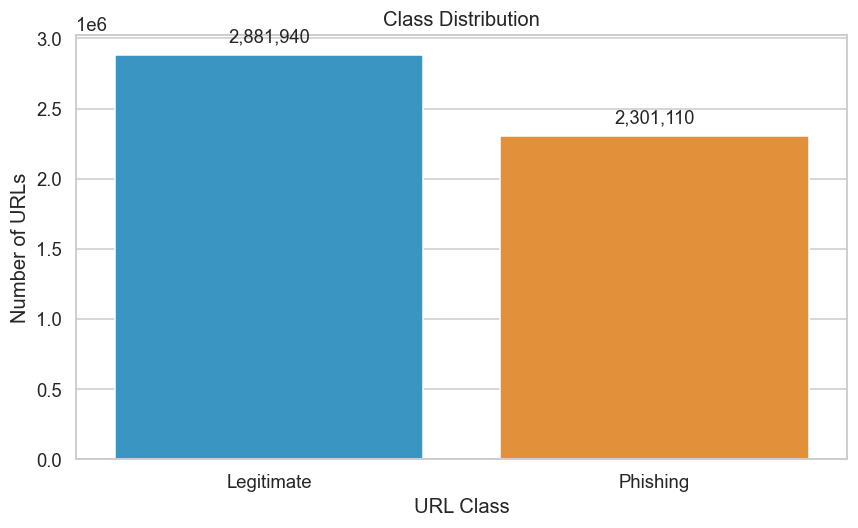

,Class,Count
0,Legitimate,2881940
1,Phishing,2301110


In [42]:
class_counts = (
    df['label'].map(CLASS_LABELS).value_counts()
    .reindex(CLASS_ORDER).rename_axis('Class').reset_index(name='Count')
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=class_counts, x='Class', y='Count', hue='Class',
            order=CLASS_ORDER, hue_order=CLASS_ORDER, palette=CLASS_COLORS,
            dodge=False, legend=False, ax=ax)
for patch, val in zip(ax.patches, class_counts['Count']):
    ax.annotate(f'{val:,.0f}',
                (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                ha='center', va='bottom', fontsize=12,
                xytext=(0, 6), textcoords='offset points')
ax.set_title('Class Distribution')
ax.set_xlabel('URL Class')
ax.set_ylabel('Number of URLs')
plt.tight_layout()
plt.show()

display(class_counts)

### 3.2 Random URL samples

Spot-check a few examples per class to verify label correctness.

In [43]:
print('Legitimate URL samples:')
display(df[df['label'] == 0][['url']].sample(n=5, random_state=42))

print('Phishing URL samples:')
display(df[df['label'] == 1][['url']].sample(n=5, random_state=42))

Legitimate URL samples:


,url
1789000,https://www.slov-lex.sk/pravne-predpisy/sk/zz/1991/423/
190135,https://buildroot.org/downloads/buildroot-2017.08.1.tar.gz.sign
4792078,https://www.ozbargain.com.au/user/12475
1232061,https://www.mamashelter.com/en/december-holiday/paris
565171,http://ccmixter.org/reviews/fireproof_babies/13078


Phishing URL samples:


,url
4114235,http://warfasi.mcdir.ru/
3090753,http://entrenadoresdeperroscolombia.com/links/autts/index.htm
819466,http://elgod.tmdhosting930.com/i/paypol-renew.com.login.54s5d48960qq14a2a1s0d5d8a12s0d5a8g6h0/
3132745,http://www.snookeycleaningservices.com//mambots/ws/emotors//loginverify.php
5048917,http://www.validupdate.com/paypal/lang/fr/service/mptt/activation/webscr_fichiers/user/2e61edb99ca1c322ef5607fd8f3c9127/login.php


### 3.3 URL Length Distribution by Class

**Hypothesis:** Phishing URLs tend to be longer — attackers embed trusted-looking brand names
(`paypal`, `amazon`) inside a long path or subdomain chain, pushing the total character count up.

**What to look for:** A rightward shift in the phishing distribution relative to legitimate URLs.

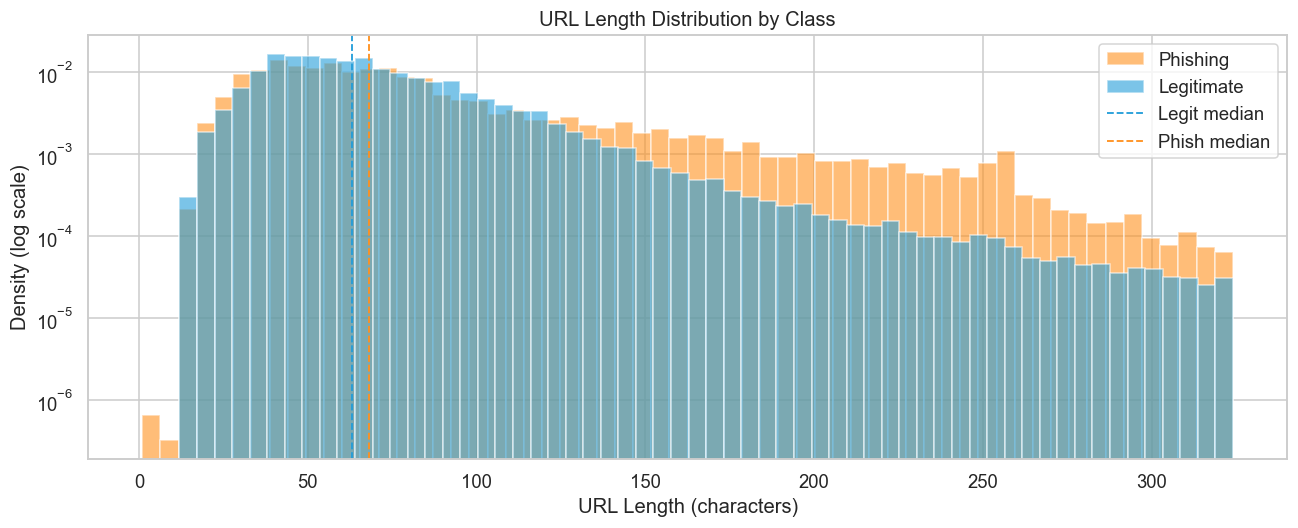

Median URL length — Legitimate: 63 chars | Phishing: 68 chars


In [44]:
plot_df = df.copy()
plot_df['URLLength'] = plot_df['url'].str.len()
plot_df['Class'] = plot_df['label'].map(CLASS_LABELS)

cap = plot_df['URLLength'].quantile(0.995)

fig, ax = plt.subplots(figsize=(12, 5))
for cls, grp in plot_df[plot_df['URLLength'] <= cap].groupby('Class', sort=False).pipe(lambda g: [(k, g.get_group(k)) for k in ['Phishing', 'Legitimate']]):
    ax.hist(grp['URLLength'], bins=60, alpha=0.6, density=True,
            label=cls, color=CLASS_COLORS[cls])

ax.set_yscale('log')
ax.set_xlabel('URL Length (characters)')
ax.set_ylabel('Density (log scale)')
ax.set_title('URL Length Distribution by Class')
ax.legend()
ax.axvline(plot_df[plot_df['label']==0]['URLLength'].median(), color=CLASS_COLORS['Legitimate'],
           linestyle='--', linewidth=1.2, label='Legit median')
ax.axvline(plot_df[plot_df['label']==1]['URLLength'].median(), color=CLASS_COLORS['Phishing'],
           linestyle='--', linewidth=1.2, label='Phish median')
ax.legend()
plt.tight_layout()
plt.show()

medians = plot_df.groupby('Class')['URLLength'].median()
print(f"Median URL length — Legitimate: {medians['Legitimate']:.0f} chars | "
      f"Phishing: {medians['Phishing']:.0f} chars")

### 3.4 TLD Frequency by Class (Top 15)

**Hypothesis:** Phishing campaigns exploit cheap or permissive TLDs (`.tk`, `.ml`, `.ga`, `.cf`, `.gq`)
that have historically been offered free of charge, lowering the cost of registering throwaway domains.

**What to look for:** TLDs that appear predominantly in the phishing class or are nearly absent in legitimate URLs.

URLs with no recognisable TLD ('unknown'): 103,715  (2.00% of dataset)  |  100.0% are phishing

Sample 'unknown' TLD URLs (phishing):


,url
2344758,http://203.101.42.145/www.ebay.com/index.html
3111088,http://163.26.173.7/~test/formslogin.htm
4839553,http://187.113.34.94/syscef.php
4505489,http://103.25.202.118/caixa/
2843230,http://198.65.23.128/


Sample 'unknown' TLD URLs (legitimate):


,url


→ Likely raw IP addresses or localhost URLs — excluded from TLD chart below.



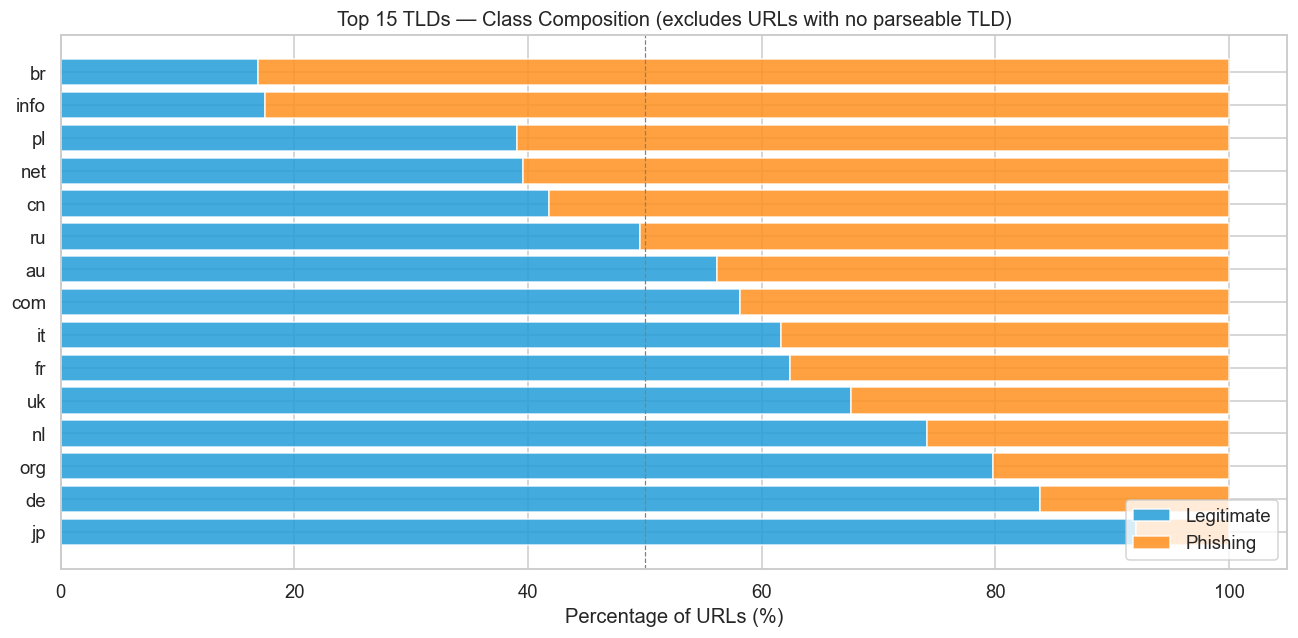

In [45]:
tld_series = df['url'].apply(lambda u: tldextract.extract(u).suffix.split('.')[-1].lower()
                              if tldextract.extract(u).suffix else 'unknown')
tld_df = df.copy()
tld_df['tld']   = tld_series
tld_df['Class'] = tld_df['label'].map(CLASS_LABELS)

# Report 'unknown' separately — these are raw IPs / malformed URLs
unknown_df    = tld_df[tld_df['tld'] == 'unknown']
unknown_phish = (unknown_df['label'] == 1).mean() * 100
print(f"URLs with no recognisable TLD ('unknown'): {len(unknown_df):,}  "
      f"({len(unknown_df)/len(tld_df)*100:.2f}% of dataset)  |  "
      f"{unknown_phish:.1f}% are phishing")

# Show what these URLs actually look like
print("\nSample 'unknown' TLD URLs (phishing):")
display(unknown_df[unknown_df['label'] == 1][['url']].sample(n=min(5, (unknown_df['label']==1).sum()), random_state=42))
print("Sample 'unknown' TLD URLs (legitimate):")
display(unknown_df[unknown_df['label'] == 0][['url']].sample(n=min(5, (unknown_df['label']==0).sum()), random_state=42))
print("→ Likely raw IP addresses or localhost URLs — excluded from TLD chart below.\n")

# Top 15 real TLDs (exclude 'unknown')
real_tlds = tld_df[tld_df['tld'] != 'unknown']
top_tlds = real_tlds['tld'].value_counts().head(15).index
tld_counts = (
    real_tlds[real_tlds['tld'].isin(top_tlds)]
    .groupby(['tld', 'Class']).size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER)
)
tld_counts_pct = tld_counts.div(tld_counts.sum(axis=1), axis=0) * 100
tld_counts_pct = tld_counts_pct.sort_values('Phishing', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bottom = None
for cls in CLASS_ORDER:
    vals = tld_counts_pct[cls].values
    ax.barh(tld_counts_pct.index, vals, left=bottom,
            color=CLASS_COLORS[cls], label=cls, alpha=0.85)
    bottom = vals if bottom is None else bottom + vals

ax.set_xlabel('Percentage of URLs (%)')
ax.set_title('Top 15 TLDs — Class Composition (excludes URLs with no parseable TLD)')
ax.axvline(50, color='grey', linestyle='--', linewidth=0.8)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## SECTION 4 — Key Takeaways

| Observation | Implication for Feature Engineering |
|---|---|
| Phishing URLs are consistently longer | `URLLength` will be a strong numeric feature |
| Phishing URLs have a wider length variance | Log-transform likely needed to normalise skew |
| Certain TLDs (`.tk`, `.ml`, `.ga`) skew heavily phishing | TLD-based features (length, entropy) worth including |
| Dataset is near-balanced (~56 % legit / 44 % phishing) | Class weights still recommended; no heavy resampling needed |
| 2 % of URLs have no parseable TLD — 100 % are phishing | These are raw IP-address URLs; captured cleanly by `HasIPAddress` binary feature |

### Known dataset limitation
URLs with raw IP addresses (`http://x.x.x.x/...`) are **100% phishing in this dataset**, likely because
the data sources focus on public web traffic and do not include internal/corporate IP-based tools.

> **Deployment caveat:** In environments where legitimate internal services use IP addresses
> (corporate intranets, dev servers), the model may over-predict phishing on those URLs.
> The `HasIPAddress` feature encodes this signal directly — the model does not need to infer
> it from the TLD, so no URLs need to be removed from training.

> Proceed to `02_feature_engineering.ipynb` to extract 25 structural features and validate them visually.